In [1]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("paper_trading.db")

trades = pd.read_sql_query("""
SELECT *
FROM trades
ORDER BY timestamp
""", conn)

display(trades)

,trade_id,timestamp,ticker,side,quantity,execution_price,fees,realized_pnl
0,1,2026-09-23T22:50:08.319719+00:00,AAPL,BUY,10.0,200.0,0.0,0.0
1,2,2026-09-23T22:53:32.624972+00:00,AAPL,SELL,5.0,220.0,0.0,100.0


In [2]:

performance_query = """
WITH closed_trades AS (
    SELECT
        ticker,
        quantity,
        execution_price,
        fees,
        realized_pnl
    FROM trades
    WHERE side = 'SELL'
)
SELECT
    COUNT(*) AS sell_transactions,
    ROUND(SUM(realized_pnl), 2) AS total_realized_pnl,
    ROUND(AVG(realized_pnl), 2) AS avg_pnl_per_sale,
    ROUND(
        100.0 * SUM(
            CASE WHEN realized_pnl > 0 THEN 1 ELSE 0 END
        ) / NULLIF(COUNT(*), 0),
        2
    ) AS win_rate_pct,
    ROUND(
        SUM(CASE WHEN realized_pnl > 0
                 THEN realized_pnl ELSE 0 END),
        2
    ) AS gross_profit,
    ROUND(
        SUM(CASE WHEN realized_pnl < 0
                 THEN -realized_pnl ELSE 0 END),
        2
    ) AS gross_loss
FROM closed_trades
"""

performance = pd.read_sql_query(
    performance_query, conn
)

display(performance)

,sell_transactions,total_realized_pnl,avg_pnl_per_sale,win_rate_pct,gross_profit,gross_loss
0,1,100.0,100.0,100.0,100.0,0.0


In [3]:

ticker_performance = pd.read_sql_query("""
SELECT
    ticker,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN side = 'BUY'
             THEN quantity ELSE 0 END) AS shares_bought,
    SUM(CASE WHEN side = 'SELL'
             THEN quantity ELSE 0 END) AS shares_sold,
    ROUND(SUM(realized_pnl), 2) AS realized_pnl
FROM trades
GROUP BY ticker
ORDER BY realized_pnl DESC
""", conn)

display(ticker_performance)

,ticker,total_transactions,shares_bought,shares_sold,realized_pnl
0,AAPL,2,10.0,5.0,100.0


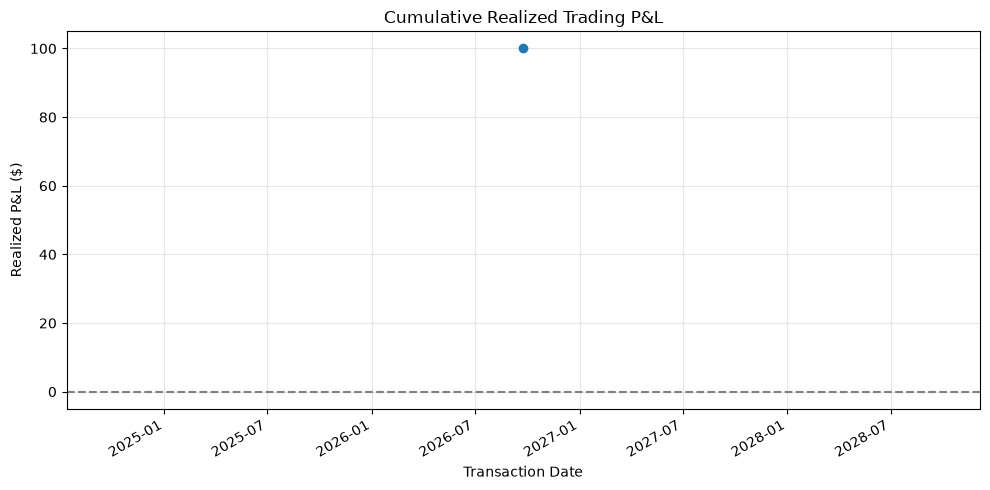

In [4]:

sell_trades = pd.read_sql_query("""
SELECT
    timestamp,
    ticker,
    realized_pnl
FROM trades
WHERE side = 'SELL'
ORDER BY timestamp, trade_id
""", conn)

sell_trades["timestamp"] = pd.to_datetime(
    sell_trades["timestamp"], utc=True
)

sell_trades["cumulative_realized_pnl"] = (
    sell_trades["realized_pnl"].cumsum()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    sell_trades["timestamp"],
    sell_trades["cumulative_realized_pnl"],
    marker="o"
)

ax.axhline(0, linestyle="--", color="gray")
ax.set_title("Cumulative Realized Trading P&L")
ax.set_xlabel("Transaction Date")
ax.set_ylabel("Realized P&L ($)")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:

conn.execute("""
CREATE TABLE IF NOT EXISTS equity_snapshots (
    snapshot_id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT NOT NULL,
    cash_balance REAL NOT NULL,
    holdings_value REAL NOT NULL,
    total_equity REAL NOT NULL
)
""")

conn.commit()

print("Equity snapshots table created.")


Equity snapshots table created.


In [6]:

from datetime import datetime, timezone

# Illustrative price used in our simulation
market_prices = {"AAPL": 220.0}

positions = pd.read_sql_query(
    "SELECT * FROM positions", conn
)

account = pd.read_sql_query(
    "SELECT cash_balance FROM accounts WHERE account_id = 1",
    conn
)

cash = float(account.loc[0, "cash_balance"])

missing = set(positions["ticker"]) - set(market_prices)
if missing:
    raise ValueError(f"Missing prices for: {missing}")

positions["market_price"] = positions["ticker"].map(
    market_prices
)

positions["market_value"] = (
    positions["quantity"] * positions["market_price"]
)

holdings_value = float(positions["market_value"].sum())
total_equity = cash + holdings_value

conn.execute("""
INSERT INTO equity_snapshots (
    timestamp,
    cash_balance,
    holdings_value,
    total_equity
)
VALUES (?, ?, ?, ?)
""", (
    datetime.now(timezone.utc).isoformat(),
    cash,
    holdings_value,
    total_equity
))

conn.commit()

print(f"Cash: ${cash:,.2f}")
print(f"Holdings: ${holdings_value:,.2f}")
print(f"Total equity: ${total_equity:,.2f}")

Cash: $99,100.00
Holdings: $1,100.00
Total equity: $100,200.00


In [7]:

equity_history = pd.read_sql_query("""
SELECT
    timestamp,
    cash_balance,
    holdings_value,
    total_equity
FROM equity_snapshots
ORDER BY timestamp, snapshot_id
""", conn)

display(equity_history)

,timestamp,cash_balance,holdings_value,total_equity
0,2026-09-23T23:06:00.197217+00:00,99100.0,1100.0,100200.0


In [8]:

account_summary = pd.read_sql_query("""
WITH latest_snapshot AS (
    SELECT *
    FROM equity_snapshots
    ORDER BY timestamp DESC, snapshot_id DESC
    LIMIT 1
)
SELECT
    a.starting_capital,
    s.cash_balance,
    s.holdings_value,
    s.total_equity,
    ROUND(
        s.total_equity - a.starting_capital, 2
    ) AS total_pnl,
    ROUND(
        100.0 *
        (s.total_equity / a.starting_capital - 1),
        2
    ) AS total_return_pct
FROM accounts a
CROSS JOIN latest_snapshot s
WHERE a.account_id = 1
""", conn)

display(account_summary)

,starting_capital,cash_balance,holdings_value,total_equity,total_pnl,total_return_pct
0,100000.0,99100.0,1100.0,100200.0,200.0,0.2
